# 03 · The Loss Landscape

> **Series:** How a Convolutional Neural Network Learns
> **Prerequisites:** notebooks 01 and 02
> **Renders to:** `results/03_gradient_descent.gif`, `results/03_learning_rate.gif`,
> a portrait cut as `…_feed.gif` + `…_feed.mp4`, and the stills
> `results/03_cross_entropy.png`, `results/03_feature_space.png`,
> `results/03_slice_1d.png`, `results/03_landscape_2d.png`,
> `results/03_steepest_direction.png`, `results/03_loss_barrier.png`

Every kernel in notebooks 01 and 02 was **designed**. We chose the
orientations, drew the Gaussian envelope by hand, and set the thresholds by
looking at a percentile of the data. The architecture was real; the parameters
were ours.

A trained network gets its parameters from one number: how wrong it was. This
notebook is about that number — what it is, what it looks like as a *surface*
over the parameters, and why walking downhill on that surface is a sane thing
to do.

The trick that makes it visible is to build a model with exactly **two**
parameters. Not a slice through a larger network, not a projection — two
parameters, so the contour plot on screen is the entire loss function, with
nothing hidden behind the page.


## 1. Setup

Same opening as every notebook in the series: import `cnnviz`, apply the shared
visual style, fix a seed. Theme and language are switches, not rewrites.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch
from IPython.display import Image, display

from cnnviz import animate, formats, panels, results, style, text
from cnnviz.data import load_mnist
from cnnviz.layers import (
    Conv2D,
    Dense,
    Flatten,
    MaxPool2D,
    ReLU,
    Sequential,
    softmax_cross_entropy,
)

style.use_project_style(theme="dark")
text.set_language("en")

RNG = np.random.default_rng(0)
NOTEBOOK = 3


## 2. A loss is one number for "how wrong"

A network outputs scores. To train it we need a single number that gets
*smaller* as those scores get better, because "smaller" is the only instruction
we know how to follow.

For classification that number is almost always **cross-entropy**. Turn the
scores into a probability distribution with a softmax, then take the negative
log of the probability assigned to the right answer:

$$
L \;=\; -\log p_{\text{correct}},
\qquad
p_i \;=\; \frac{e^{z_i}}{\sum_j e^{z_j}}
$$

`cnnviz.layers.softmax_cross_entropy` implements this pair fused together, for
the numerical reason given in its docstring. What matters here is the *shape*
of $-\log p$, and one property in particular: it is **unbounded above**. Being
wrong has no worst case. A network that assigns 1% to the true class is
punished roughly five times as hard as one that assigns 50%, and that is
deliberate — the penalty for confident nonsense has to outweigh the reward for
confident correctness, or a model learns to bluff.


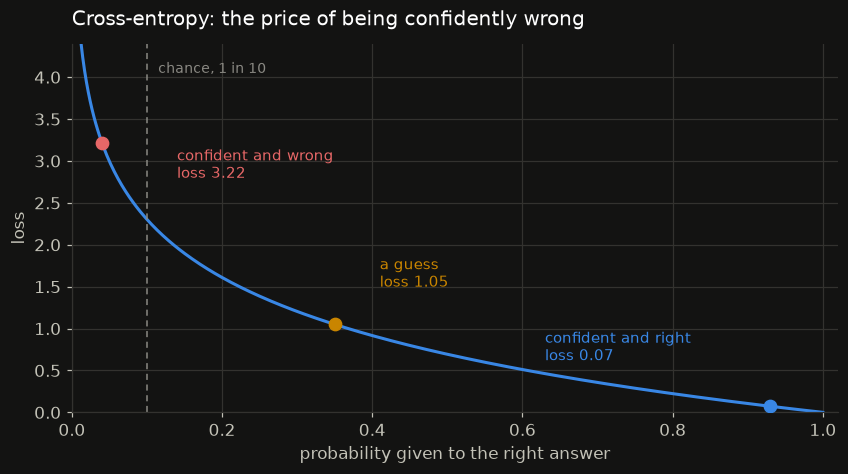

In [2]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
p = np.linspace(0.012, 1.0, 400)
ax.plot(p, -np.log(p), color=style.CATEGORICAL[0])

# Three predictions worth naming, each in its own categorical slot.
for value, key, slot, dx, dy in (
    (0.93, "ce_confident_right", 0, -0.30, 0.55),
    (0.35, "ce_unsure", 3, 0.06, 0.45),
    (0.04, "ce_confident_wrong", 7, 0.10, -0.42),
):
    ax.plot([value], [-np.log(value)], "o", color=style.CATEGORICAL[slot], zorder=5)
    ax.annotate(
        f"{text.t(key)}\n{text.t('loss_axis')} {text.num(-np.log(value))}",
        xy=(value, -np.log(value)), xytext=(value + dx, -np.log(value) + dy),
        fontsize=9.5, color=style.CATEGORICAL[slot],
    )

ax.axvline(0.1, color=style.INK_MUTED, linestyle=(0, (4, 3)), linewidth=1.0)
ax.text(0.115, 4.05, text.t("ce_chance"), fontsize=9, color=style.INK_MUTED)
ax.set_xlabel(text.t("ce_x"))
ax.set_ylabel(text.t("loss_axis"))
ax.set_title(text.t("ce_title"))
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 4.4)

fig.savefig(results.output_path("cross_entropy.png", notebook=NOTEBOOK))
plt.show()


## 3. A model small enough to see all of

A loss is a function of the parameters. To *draw* it we need few enough
parameters to fit on a page, so we build a classifier with exactly two.

The front end is the stack from notebook 02, **frozen**: four oriented edge
kernels, a ReLU, one round of max-pooling. It contributes no trainable
parameters here; it is a fixed measuring instrument that turns a digit into
four feature maps.

From those maps we take two numbers per image. The mean activation of each
channel is the obvious choice and the wrong one: it is dominated by how much
ink the digit happens to contain, so any two channels come out nearly
proportional to each other and the resulting loss surface is a knife edge. So
we divide each channel's energy by the total instead. That makes the features a
**composition** — *what share of this digit's edge energy runs at 45°* — which
is a property of shape rather than of thickness.

Standardising the pair to zero mean and unit variance finishes the job. It also
means the fitted bias is negligible (we check this below), so we can hold the
bias at zero and let the two weights be the whole model:

$$
s \;=\; w_1 z_1 + w_2 z_2,
\qquad
L(w_1, w_2) \;=\; \frac{1}{N}\sum_{n} \Bigl[\log\bigl(1 + e^{s_n}\bigr) - y_n s_n\Bigr]
$$

That is binary cross-entropy written for a single logit. Two parameters, one
number out, and every value on the contour plots below is this expression
evaluated on 500 actual MNIST digits.


In [3]:
def oriented_edge(degrees, size=5, sigma=1.2):
    """A `size`x`size` edge detector for edges running at `degrees` — from notebook 02."""
    r = np.arange(size) - size // 2
    u, v = np.meshgrid(r, r, indexing="ij")
    theta = np.radians(degrees)

    w = (v * np.cos(theta) + u * np.sin(theta))
    w = w * np.exp(-(u ** 2 + v ** 2) / (2 * sigma ** 2))
    w -= w.mean()
    return (w / w[w > 0].sum()).astype(np.float32)


ANGLES = (0, 45, 90, 135)
POS, NEG = 2, 7          # the two digits to tell apart
CHANNELS = (1, 2)        # the 45° and 90° kernels
N_PER = 250

conv1 = Conv2D(1, 4, kernel_size=5, padding=2, seed=0)
conv1.W = np.stack([oriented_edge(a) for a in ANGLES])[:, None]
conv1.b = np.zeros(4, dtype=np.float32)
front = Sequential(conv1, ReLU(), MaxPool2D(2))

images, labels = load_mnist(train=True, normalize=False)
index = np.concatenate([np.flatnonzero(labels == NEG)[:N_PER],
                        np.flatnonzero(labels == POS)[:N_PER]])
digits = images[index]
y = (labels[index] == POS).astype(np.float64)

maps = front.forward(digits)                       # (N, 4, 14, 14)
energy = maps.mean(axis=(2, 3))                    # (N, 4)
# Composition, not magnitude: dividing by the total removes the "how much ink
# is in this image" factor that otherwise dominates every channel at once.
share = energy / energy.sum(axis=1, keepdims=True)

z = share[:, list(CHANNELS)].astype(np.float64)
Z = (z - z.mean(0)) / z.std(0)

print(f"{len(Z)} digits, {Z.shape[1]} features each")
print(f"correlation between the two features   {np.corrcoef(Z.T)[0, 1]:+.3f}")


500 digits, 2 features each
correlation between the two features   +0.052


The loss and its gradient, written out. Both are three lines, and both are
about to be checked rather than trusted.

`np.logaddexp(0, s)` is $\log(1 + e^{s})$ computed without overflowing for
large $s$ — the same defensive move as subtracting the row max inside a
softmax.


In [4]:
def loss_at(w1, w2):
    """Binary cross-entropy of the two-weight model, on all 500 digits."""
    s = Z[:, 0] * w1 + Z[:, 1] * w2
    return float(np.mean(np.logaddexp(0.0, s) - y * s))


def grad_at(w):
    """dL/dw. For this model it is Zᵀ(p − y)/N — the error, projected back."""
    p = 1.0 / (1.0 + np.exp(-(Z @ np.asarray(w, dtype=float))))
    return Z.T @ (p - y) / len(y)


# Fit the two weights properly, so every figure below can mark the true bottom.
W_STAR = np.zeros(2)
for _ in range(20000):
    W_STAR -= 3.0 * grad_at(W_STAR)

L_STAR = loss_at(*W_STAR)
probs = 1.0 / (1.0 + np.exp(-(Z @ W_STAR)))
ACC = float(((probs > 0.5) == (y > 0.5)).mean())

# And the bias we claimed we could ignore: fit it jointly and look at it.
Zb = np.hstack([Z, np.ones((len(Z), 1))])
wb = np.zeros(3)
for _ in range(20000):
    pb = 1.0 / (1.0 + np.exp(-(Zb @ wb)))
    wb -= 3.0 * (Zb.T @ (pb - y) / len(y))

print(f"best weights      w* = ({W_STAR[0]:+.3f}, {W_STAR[1]:+.3f})")
print(f"loss there        {L_STAR:.4f}")
print(f"accuracy there    {ACC:.1%}")
print(f"bias, if fitted   {wb[2]:+.4f}   (small enough to hold at zero)")


best weights      w* = (-1.781, +2.013)
loss there        0.3531
accuracy there    84.6%
bias, if fitted   +0.0251   (small enough to hold at zero)


84.6%, not 99%. That number is the reason this problem is worth using: the two
clouds below genuinely overlap, so the loss has a real minimum at a finite
place, with a floor above zero. A separable problem would have its optimum at
infinity and no bottom to walk to.


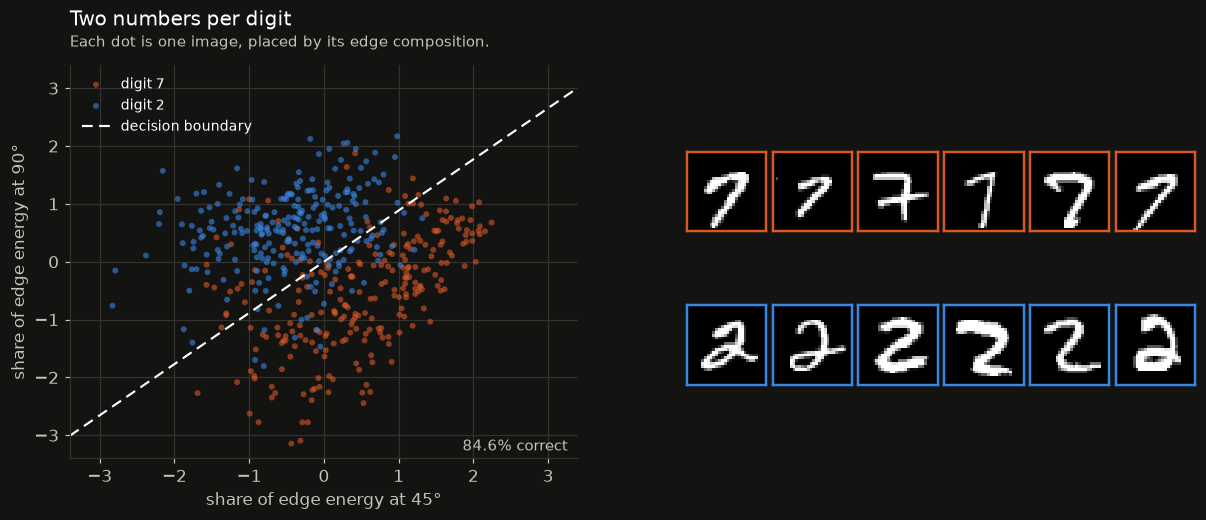

In [5]:
SLOT = {0: 5, 1: 0}      # class -> categorical slot, fixed for the notebook

fig = plt.figure(figsize=(11.0, 4.8))
fig.set_layout_engine("none")

gs = GridSpec(1, 1, figure=fig, left=0.055, right=0.475, top=0.88, bottom=0.135)
ax = fig.add_subplot(gs[0, 0])
for cls, digit in ((0, NEG), (1, POS)):
    m = y == cls
    ax.scatter(Z[m, 0], Z[m, 1], s=15, alpha=0.6, edgecolors="none",
               color=style.CATEGORICAL[SLOT[cls]],
               label=text.t("digit_class", d=digit))

line = np.linspace(-3.4, 3.4, 2)
ax.plot(line, -W_STAR[0] / W_STAR[1] * line, color=style.INK_PRIMARY,
        linewidth=1.4, linestyle=(0, (5, 3)), label=text.t("boundary"))
ax.set_xlabel(text.t("feature_x"))
ax.set_ylabel(text.t("feature_y"))
ax.set_xlim(-3.4, 3.4)
ax.set_ylim(-3.4, 3.4)
ax.legend(loc="upper left", fontsize=9)
ax.text(0.98, 0.02, text.t("correct_share", p=text.num(ACC * 100, 1)),
        transform=ax.transAxes, ha="right", fontsize=10,
        color=style.INK_SECONDARY)

# The digits themselves, so "each dot is an image" is shown rather than claimed.
strip = GridSpec(2, 6, figure=fig, left=0.565, right=0.985, top=0.775,
                 bottom=0.215, wspace=0.08, hspace=0.08)
for row, cls in ((0, 0), (1, 1)):
    for col, i in enumerate(np.flatnonzero(y == cls)[:6]):
        sub = fig.add_subplot(strip[row, col])
        panels.draw_matrix(sub, digits[i, 0], mode="pixels", grid=False)
        for spine in sub.spines.values():
            spine.set_visible(True)
            spine.set_color(style.CATEGORICAL[SLOT[cls]])
            spine.set_linewidth(1.6)

fig.text(0.055, 0.955, text.t("features_title"), fontsize=13,
         color=style.INK_PRIMARY)
fig.text(0.055, 0.915, text.t("features_subtitle"), fontsize=10,
         color=style.INK_SECONDARY)

fig.savefig(results.output_path("feature_space.png", notebook=NOTEBOOK))
plt.show()


## 4. One weight at a time

Hold $w_2$ still and sweep $w_1$. The loss traces out a curve, and at each
point on it the **gradient is the slope of the tangent** — nothing more
mysterious than that.

Three tangents are drawn below. Read the signs: on the right the slope is
positive, so increasing $w_1$ increases the loss and the way down is to the
*left*. At the bottom the slope is zero, which is both how we recognise the
minimum and why descent stops there.

Before drawing anything we check `grad_at` against finite differences. The
project's rule from notebook 02 applies with more force here: a subtly wrong
gradient still descends *something*, and the animation would confidently show a
lie.


In [6]:
EPS = 1e-6
for probe in ([3.2, 2.0], [0.2, 2.0], [-1.0, -1.0], [2.5, -2.0]):
    analytic = grad_at(probe)
    numeric = np.array([
        (loss_at(probe[0] + EPS, probe[1]) - loss_at(probe[0] - EPS, probe[1])),
        (loss_at(probe[0], probe[1] + EPS) - loss_at(probe[0], probe[1] - EPS)),
    ]) / (2 * EPS)
    error = np.abs(analytic - numeric).max() / max(np.abs(numeric).max(), 1e-12)
    print(f"w = ({probe[0]:+.1f}, {probe[1]:+.1f})   "
          f"analytic ({analytic[0]:+.5f}, {analytic[1]:+.5f})   "
          f"relative error {error:.2e}")


w = (+3.2, +2.0)   analytic (+0.55378, -0.05488)   relative error 2.91e-10
w = (+0.2, +2.0)   analytic (+0.28119, +0.03977)   relative error 1.51e-10
w = (-1.0, -1.0)   analytic (+0.04413, -0.45167)   relative error 7.59e-11
w = (+2.5, -2.0)   analytic (+0.51958, -0.50068)   relative error 6.86e-10


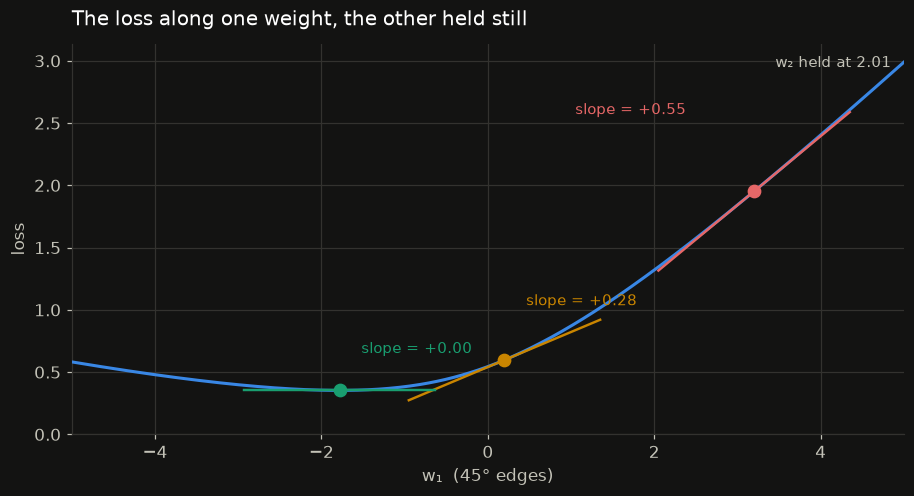

In [7]:
LIM = 5.0

fig, ax = plt.subplots(figsize=(8.2, 4.4))
grid = np.linspace(-LIM, LIM, 400)
curve = np.array([loss_at(g, W_STAR[1]) for g in grid])
ax.plot(grid, curve, color=style.CATEGORICAL[0], zorder=3)

# The label offsets are per-point: a tangent's own line is the thing most
# likely to sit where its label wants to go, so the steep one is set upslope
# and to the left instead of following it.
for w1, slot, dx, dy in ((3.2, 7, -2.15, 0.62), (0.2, 3, 0.26, 0.44),
                         (float(W_STAR[0]), 4, 0.26, 0.30)):
    value = loss_at(w1, W_STAR[1])
    slope = grad_at([w1, W_STAR[1]])[0]
    span = np.array([-1.15, 1.15])
    ax.plot(w1 + span, value + slope * span, color=style.CATEGORICAL[slot],
            linewidth=1.6, zorder=4)
    ax.plot([w1], [value], "o", color=style.CATEGORICAL[slot], zorder=5)
    ax.annotate(text.t("slope_is_gradient", v=text.num(slope, 2, signed=True)),
                xy=(w1, value), xytext=(w1 + dx, value + dy),
                fontsize=9.5, color=style.CATEGORICAL[slot])

ax.set_xlabel(text.t("w1_axis"))
ax.set_ylabel(text.t("loss_axis"))
ax.set_title(text.t("slice_title"))
ax.text(0.985, 0.94, text.t("held_at", v=text.num(W_STAR[1])),
        transform=ax.transAxes, ha="right", fontsize=9.5,
        color=style.INK_SECONDARY)
ax.set_xlim(-LIM, LIM)
ax.set_ylim(0, curve.max() * 1.05)

fig.savefig(results.output_path("slice_1d.png", notebook=NOTEBOOK))
plt.show()


## 5. Both weights: the landscape

Release $w_2$ and the curve becomes a surface. Because the model has only these
two parameters, **this contour plot is the entire loss function** — not a slice,
not a projection. Everything the optimiser can possibly do happens inside this
square.

On the colour: loss is an unsigned magnitude, so it takes the sequential ramp
by the rule from `style.py`, which on the dark theme runs dark → light as
magnitude grows. The consequence is worth stating plainly, because it inverts
the usual topographic instinct: **the dark region is the good one.** The basin
recedes toward the surface colour and the expensive ground glows. Contour
lines carry the shape either way, and consistency with the rest of the series
is worth more than one figure's convenience.

The dashed line marks where section 4 took its cut.


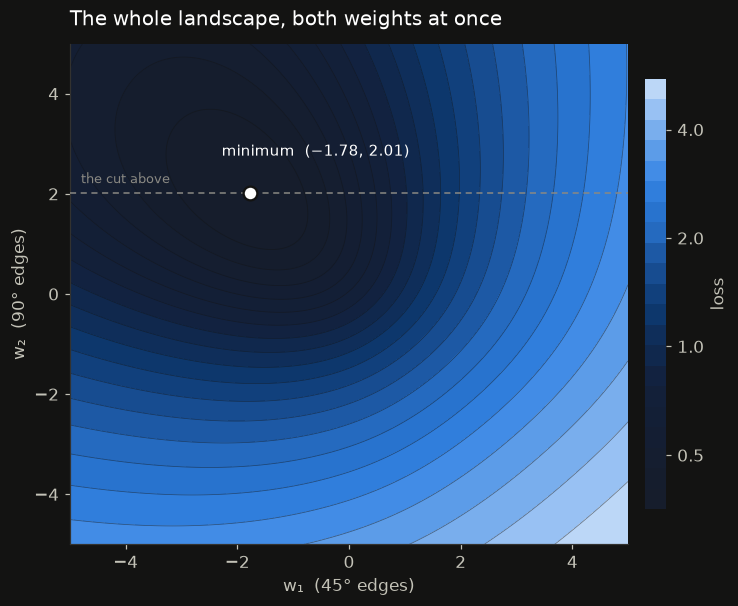

In [8]:
GRID = 241
axis = np.linspace(-LIM, LIM, GRID)
W1, W2 = np.meshgrid(axis, axis)
L = np.array([[loss_at(a, b) for a in axis] for b in axis])

# Geometric levels, not linear: the loss spans an order of magnitude across the
# window, and evenly spaced levels would put every ring in the expensive corner
# and none in the basin the figure is about.
LEVELS = np.geomspace(L.min(), L.max(), 22)

fig, ax = plt.subplots(figsize=(6.6, 5.4))
filled = ax.contourf(W1, W2, L, levels=LEVELS, cmap=style.CMAP_MAGNITUDE)
ax.contour(W1, W2, L, levels=LEVELS, colors=style.SURFACE, linewidths=0.5,
           alpha=0.5)
ax.plot([W_STAR[0]], [W_STAR[1]], "o", color=style.FOCUS, markersize=9,
        markeredgecolor=style.SURFACE, markeredgewidth=1.5, zorder=6)
ax.annotate(
    f"{text.t('minimum_here')}  ({text.num(W_STAR[0])}, {text.num(W_STAR[1])})",
    xy=W_STAR, xytext=(W_STAR[0] - 0.5, W_STAR[1] + 0.75),
    fontsize=10, color=style.FOCUS,
)
ax.axhline(W_STAR[1], color=style.INK_MUTED, linestyle=(0, (4, 3)),
           linewidth=1.0, zorder=5)
ax.text(-LIM + 0.2, W_STAR[1] + 0.2, text.t("slice_cut"), fontsize=8.5,
        color=style.INK_MUTED)
ax.set_xlabel(text.t("w1_axis"))
ax.set_ylabel(text.t("w2_axis"))
ax.set_title(text.t("landscape_title"))
ax.grid(False)

bar = fig.colorbar(filled, ax=ax, shrink=0.86, pad=0.03)
bar.set_label(text.t("loss_axis"))
# Round ticks, not the geometric level values: the levels were chosen to space
# the bands, and printing them turns the bar into a list of arbitrary decimals.
bar.set_ticks([0.5, 1.0, 2.0, 4.0])
bar.set_ticklabels([text.num(v, 1) for v in (0.5, 1.0, 2.0, 4.0)])
bar.outline.set_visible(False)

fig.savefig(results.output_path("landscape_2d.png", notebook=NOTEBOOK))
plt.show()


## 6. Why the gradient, and not some other direction?

The claim is that $-\nabla L$ is the direction of steepest descent. It is
usually asserted. It can be measured.

Stand at a point, pick a direction $\hat{d}$, take a tiny step along it, and
divide the drop in loss by the step length. Do that for 24 directions spanning
the circle. Calculus says the answer must be

$$
\lim_{\varepsilon \to 0} \frac{L(\mathbf{w}) - L(\mathbf{w} + \varepsilon \hat{d})}{\varepsilon}
\;=\; -\nabla L \cdot \hat{d}
\;=\; \lVert \nabla L \rVert \cos\theta
$$

— a cosine, peaking exactly when $\hat{d}$ points along $-\nabla L$, with
height $\lVert \nabla L \rVert$. The dots below are the 24 measurements. The
line is that prediction, drawn from the gradient alone with nothing fitted.


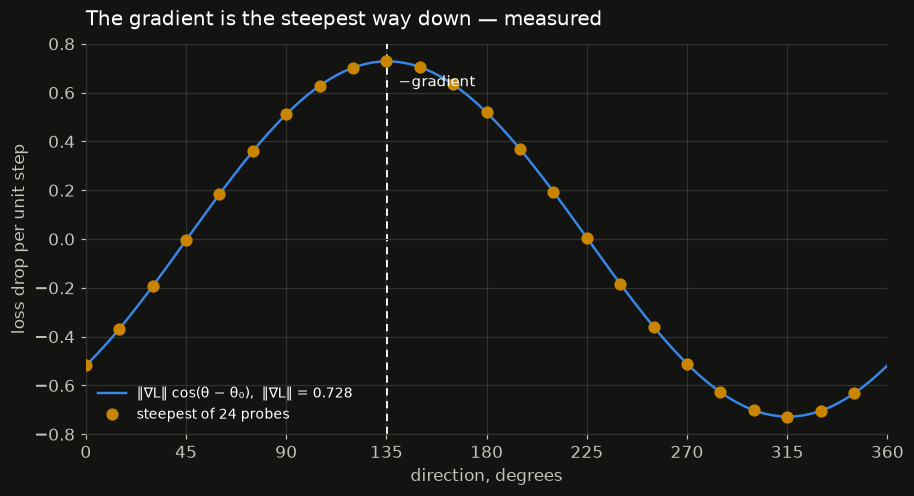

−gradient points at        135.4°
steepest of 24 probes at    135.0°   (the probes are 15° apart)
best measured drop         0.7279
‖∇L‖                       0.7279


In [9]:
PROBE = np.array([2.6, -2.2])
N_PROBES = 24
STEP = 1e-4

angles = np.linspace(0, 2 * np.pi, N_PROBES, endpoint=False)
base = loss_at(*PROBE)
drops = np.array([
    (base - loss_at(*(PROBE + STEP * np.array([np.cos(a), np.sin(a)])))) / STEP
    for a in angles
])

g = grad_at(PROBE)
downhill = np.arctan2(-g[1], -g[0]) % (2 * np.pi)
smooth = np.linspace(0, 2 * np.pi, 400)
predicted = np.linalg.norm(g) * np.cos(smooth - downhill)

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.plot(np.degrees(smooth), predicted, color=style.CATEGORICAL[0], linewidth=1.6,
        zorder=2, label=f"‖∇L‖ cos(θ − θ₀),  ‖∇L‖ = {text.num(np.linalg.norm(g), 3)}")
ax.plot(np.degrees(angles), drops, "o", color=style.CATEGORICAL[3], markersize=7,
        zorder=3, label=text.t("steepest_measured", n=N_PROBES))
ax.axvline(np.degrees(downhill), color=style.FOCUS, linestyle=(0, (4, 3)),
           linewidth=1.2, zorder=1)
ax.text(np.degrees(downhill) + 5, predicted.max() * 0.86,
        text.t("steepest_negative_gradient"), fontsize=10, color=style.FOCUS)
ax.axhline(0, color=style.GRID, linewidth=0.8, zorder=1)
ax.set_xlabel(text.t("steepest_probe"))
ax.set_ylabel(text.t("steepest_drop"))
ax.set_title(text.t("steepest_title"))
ax.set_xlim(0, 360)
ax.set_xticks(range(0, 361, 45))
ax.legend(loc="lower left", fontsize=9)

fig.savefig(results.output_path("steepest_direction.png", notebook=NOTEBOOK))
plt.show()

print(f"−gradient points at        {np.degrees(downhill):.1f}°")
print(f"steepest of {N_PROBES} probes at    "
      f"{np.degrees(angles[drops.argmax()]):.1f}°   "
      f"(the probes are {360 / N_PROBES:.0f}° apart)")
print(f"best measured drop         {drops.max():.4f}")
print(f"‖∇L‖                       {np.linalg.norm(g):.4f}")


The measured points sit on the predicted cosine, and the peak lands on the
gradient direction to within the resolution of the probe. Two things follow,
and they are the whole justification for the algorithm:

- Half the directions on that circle make the loss **worse** — anywhere the
  cosine is negative. Direction is not a detail.
- The gradient is not merely *a* downhill direction, it is the best one
  available, and its length is how steep the ground is.

So the update rule is the shortest sentence in machine learning:

$$
\mathbf{w} \;\leftarrow\; \mathbf{w} \;-\; \eta \, \nabla L(\mathbf{w})
$$

Go the way the ground falls, and scale how far you go by $\eta$, the
**learning rate**.


## 7. Descent, animated

Now watch it run. Thirty-two steps from a deliberately bad starting point.

Rendering choices worth naming:

- **The arrow is the step actually taken**, $-\eta \nabla L$, not a unit vector
  pointing downhill. Its length is data. Watching it shorten as the ground
  flattens is the animation's main claim, and a normalised arrow would destroy
  exactly that.
- **The contour grid is computed once**, outside the frame callback. Recomputing
  it per frame would be thirty-two times the work for an identical picture.
- **Both panels keep fixed limits** for the whole sequence. An axis that
  rescaled to its own frame would flatten the loss curve into a horizontal line
  at every step, which is the time-axis version of the trap notebook 01
  laboured over.
- The loss curve **flattens while the point is still moving**. That is not a
  rendering artefact; it is the honest shape of training, and it is why loss
  curves are read on a log axis in the next section.


In [10]:
START = (4.2, -1.0)
LR = 1.5
STEPS = 32


def descend(lr, steps, start=START):
    """Plain gradient descent. The whole optimiser is the middle line."""
    w = np.array(start, dtype=float)
    path = [w.copy()]
    for _ in range(steps):
        w = w - lr * grad_at(w)
        path.append(w.copy())
    return np.array(path)


PATH = descend(LR, STEPS)
LOSSES = np.array([loss_at(*p) for p in PATH])
STOP, SBOTTOM = 0.760, 0.225

print(f"start  w = ({PATH[0][0]:+.2f}, {PATH[0][1]:+.2f})   loss {LOSSES[0]:.3f}")
print(f"end    w = ({PATH[-1][0]:+.2f}, {PATH[-1][1]:+.2f})   loss {LOSSES[-1]:.4f}")
print(f"best   w = ({W_STAR[0]:+.2f}, {W_STAR[1]:+.2f})   loss {L_STAR:.4f}")


def paint_surface(ax, w1, w2, values, levels, lim):
    ax.contourf(w1, w2, values, levels=levels, cmap=style.CMAP_MAGNITUDE)
    ax.contour(w1, w2, values, levels=levels, colors=style.SURFACE,
               linewidths=0.45, alpha=0.45)
    ax.plot([W_STAR[0]], [W_STAR[1]], "o", color=style.FOCUS, markersize=6,
            markeredgecolor=style.SURFACE, markeredgewidth=1.2, zorder=6)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.grid(False)


def caption_for(k):
    if k == 0:
        return text.t("descent_cap_start")
    if k <= 2:
        return text.t("descent_cap_gradient")
    if k <= 8:
        return text.t("descent_cap_steep")
    if k < STEPS:
        return text.t("descent_cap_flat")
    return text.t("descent_cap_end")


def draw_descent(fig, k):
    gs = GridSpec(1, 1, figure=fig, left=0.060, right=0.470, top=STOP,
                  bottom=SBOTTOM)
    ax = fig.add_subplot(gs[0, 0])
    paint_surface(ax, W1, W2, L, LEVELS, LIM)

    walked = PATH[:k + 1]
    ax.plot(walked[:, 0], walked[:, 1], "-", color=style.FOCUS, linewidth=1.2,
            alpha=0.8, zorder=7)
    ax.plot(walked[:, 0], walked[:, 1], "o", color=style.FOCUS, markersize=2.6,
            zorder=7)
    here = walked[-1]

    if k < STEPS:
        step = -LR * grad_at(here)
        ax.add_patch(FancyArrowPatch(
            tuple(here), tuple(here + step), arrowstyle="-|>", mutation_scale=13,
            linewidth=1.8, color=style.CATEGORICAL[3], zorder=8,
            shrinkA=6.0, shrinkB=0.0,
        ))
    ax.plot([here[0]], [here[1]], "o", color=style.CATEGORICAL[3], markersize=8.5,
            markeredgecolor=style.SURFACE, markeredgewidth=1.3, zorder=9)
    ax.set_xlabel(text.t("w1_axis"), fontsize=9.5)
    ax.set_ylabel(text.t("w2_axis"), fontsize=9.5)

    gs2 = GridSpec(1, 1, figure=fig, left=0.585, right=0.975, top=STOP,
                   bottom=SBOTTOM)
    ax2 = fig.add_subplot(gs2[0, 0])
    ax2.plot(np.arange(k + 1), LOSSES[:k + 1], color=style.CATEGORICAL[3],
             linewidth=1.8)
    ax2.axhline(L_STAR, color=style.INK_MUTED, linestyle=(0, (4, 3)),
                linewidth=1.0)
    ax2.plot([k], [LOSSES[k]], "o", color=style.CATEGORICAL[3], markersize=7)
    ax2.set_xlim(-0.7, STEPS + 0.7)
    ax2.set_ylim(0, LOSSES.max() * 1.06)
    ax2.set_xlabel(text.t("step_axis"), fontsize=9.5)
    ax2.set_ylabel(text.t("loss_axis"), fontsize=9.5)
    ax2.set_title(f"{text.t('step_of', k=k, n=STEPS)}   ·   "
                  f"{text.t('loss_now', v=text.num(LOSSES[k], 3))}", fontsize=11)

    panels.frame_header(fig, text.t("descent_title"), text.t("descent_subtitle"))
    panels.caption(fig, caption_for(k))
    panels.progress_bar(fig, k / STEPS)


animate.animate(
    draw_descent, len(PATH),
    results.output_path("gradient_descent.gif", notebook=NOTEBOOK),
    figsize=(9.2, 5.0), fps=7,
    durations=animate.hold_at(len(PATH), fps=7, holds={1: 0.5, 2: 0.4},
                              first=1.1, last=2.2),
    colors=128,
)


start  w = (+4.20, -1.00)   loss 3.129
end    w = (-1.66, +1.87)   loss 0.3539
best   w = (-1.78, +2.01)   loss 0.3531


03_gradient_descent:   0%|          | 0/33 [00:00<?, ?frame/s]

PosixPath('/Users/usuario/Desktop/howAiLearns/results/03_gradient_descent.gif')

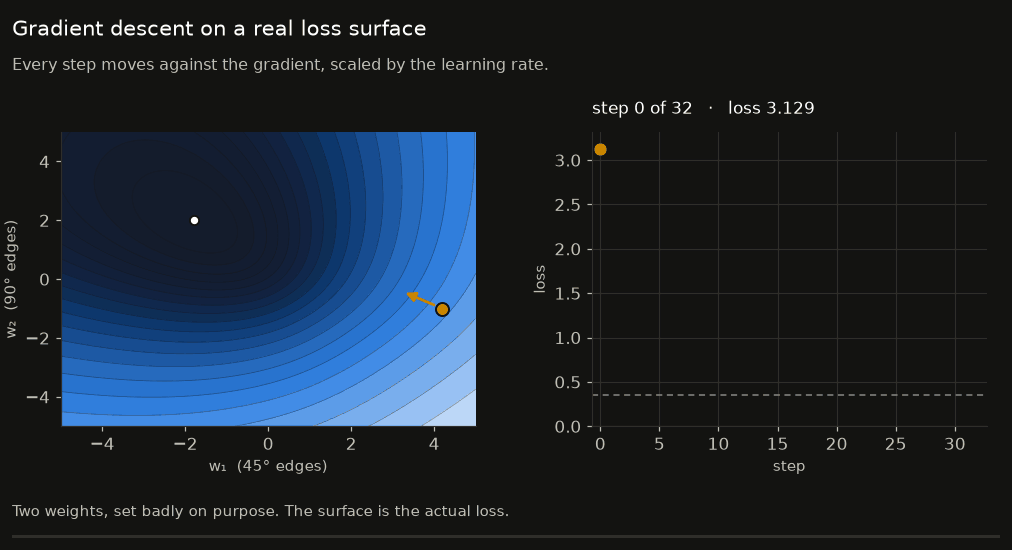

In [11]:
display(Image(filename=str(results.output_path("03_gradient_descent.gif"))))


Nobody chose the final weights. They are where the slope ran out.

That is worth sitting with, because it is the entire answer to "how does a
network learn". There is no search over configurations, no reasoning about
which feature ought to matter. There is a surface, and a rule for going
downhill on it, and the parameters are wherever that rule stops.

## 8. The learning rate

$\eta$ is the one number in the update rule we still have to choose, and the
choice is not cosmetic.

The three runs below share a surface and a starting point and differ only in
$\eta$. The loss panel is on a **log axis**: on a linear one, a run that has
arrived and a run still 0.25 short are a couple of pixels apart, and that gap
is the entire claim of the figure.


In [12]:
RATES = [(0.4, 0, "lr_too_small"), (3.0, 1, "lr_right"), (18.0, 7, "lr_too_large")]
LR_STEPS = 20
LR_LIM = 7.0

LR_PATHS = [descend(lr, LR_STEPS) for lr, _, _ in RATES]
LR_LOSSES = [np.array([loss_at(*p) for p in path]) for path in LR_PATHS]

axis_b = np.linspace(-LR_LIM, LR_LIM, 221)
W1B, W2B = np.meshgrid(axis_b, axis_b)
LB = np.array([[loss_at(a, b) for a in axis_b] for b in axis_b])
LEVELS_B = np.geomspace(LB.min(), LB.max(), 24)
CEILING = max(float(losses.max()) for losses in LR_LOSSES)

for (lr, _, key), path, losses in zip(RATES, LR_PATHS, LR_LOSSES):
    reversals = int((np.einsum(
        "ij,ij->i", np.diff(path, axis=0)[:-1], np.diff(path, axis=0)[1:]) < 0).sum())
    print(f"η = {lr:4.1f}   final loss {losses[-1]:.4f}   "
          f"excess over best {losses[-1] - L_STAR:+.4f}   "
          f"reversals {reversals:2d}   furthest |w| {np.abs(path).max():.2f}")


def draw_rates(fig, k):
    gs = GridSpec(1, 1, figure=fig, left=0.060, right=0.470, top=STOP,
                  bottom=SBOTTOM)
    ax = fig.add_subplot(gs[0, 0])
    paint_surface(ax, W1B, W2B, LB, LEVELS_B, LR_LIM)

    for (lr, slot, _), path in zip(RATES, LR_PATHS):
        walked = path[:k + 1]
        colour = style.CATEGORICAL[slot]
        ax.plot(walked[:, 0], walked[:, 1], "-", color=colour, linewidth=1.4,
                alpha=0.9, zorder=7)
        ax.plot([walked[-1, 0]], [walked[-1, 1]], "o", color=colour,
                markersize=7.5, markeredgecolor=style.SURFACE,
                markeredgewidth=1.2, zorder=9)
    ax.set_xlabel(text.t("w1_axis"), fontsize=9.5)
    ax.set_ylabel(text.t("w2_axis"), fontsize=9.5)

    gs2 = GridSpec(1, 1, figure=fig, left=0.585, right=0.975, top=STOP,
                   bottom=SBOTTOM)
    ax2 = fig.add_subplot(gs2[0, 0])
    for (lr, slot, _), losses in zip(RATES, LR_LOSSES):
        ax2.plot(np.arange(k + 1), losses[:k + 1], color=style.CATEGORICAL[slot],
                 linewidth=1.8, label=text.t("lr_label", v=text.num(lr, 1)))
        ax2.plot([k], [losses[k]], "o", color=style.CATEGORICAL[slot], markersize=6)
    ax2.axhline(L_STAR, color=style.INK_MUTED, linestyle=(0, (4, 3)), linewidth=1.0)
    ax2.set_yscale("log")
    ax2.set_xlim(-0.7, LR_STEPS + 0.7)
    ax2.set_ylim(0.30, CEILING * 1.3)
    ax2.set_xlabel(text.t("step_axis"), fontsize=9.5)
    ax2.set_ylabel(text.t("loss_axis"), fontsize=9.5)
    ax2.set_title(text.t("step_of", k=k, n=LR_STEPS), fontsize=11)
    ax2.legend(loc="upper right", fontsize=9.5)

    panels.frame_header(fig, text.t("lr_title"), text.t("lr_subtitle"))
    # The verdicts are the point of the figure, so each is set in its own
    # trajectory's colour rather than in the caption ink.
    for row, (lr, slot, key) in enumerate(RATES):
        fig.text(0.060, 0.098 - row * 0.034,
                 f"{text.num(lr, 1)}  —  {text.t(key)}", fontsize=9.5,
                 color=style.CATEGORICAL[slot], va="bottom")
    panels.progress_bar(fig, k / LR_STEPS)


animate.animate(
    draw_rates, LR_STEPS + 1,
    results.output_path("learning_rate.gif", notebook=NOTEBOOK),
    figsize=(9.2, 5.4), fps=7,
    durations=animate.hold_at(LR_STEPS + 1, fps=7, first=1.2, last=2.2),
    colors=128,
)


η =  0.4   final loss 0.6006   excess over best +0.2475   reversals  0   furthest |w| 4.20
η =  3.0   final loss 0.3533   excess over best +0.0002   reversals  0   furthest |w| 4.20
η = 18.0   final loss 0.3531   excess over best +0.0000   reversals  7   furthest |w| 6.54


03_learning_rate:   0%|          | 0/21 [00:00<?, ?frame/s]

PosixPath('/Users/usuario/Desktop/howAiLearns/results/03_learning_rate.gif')

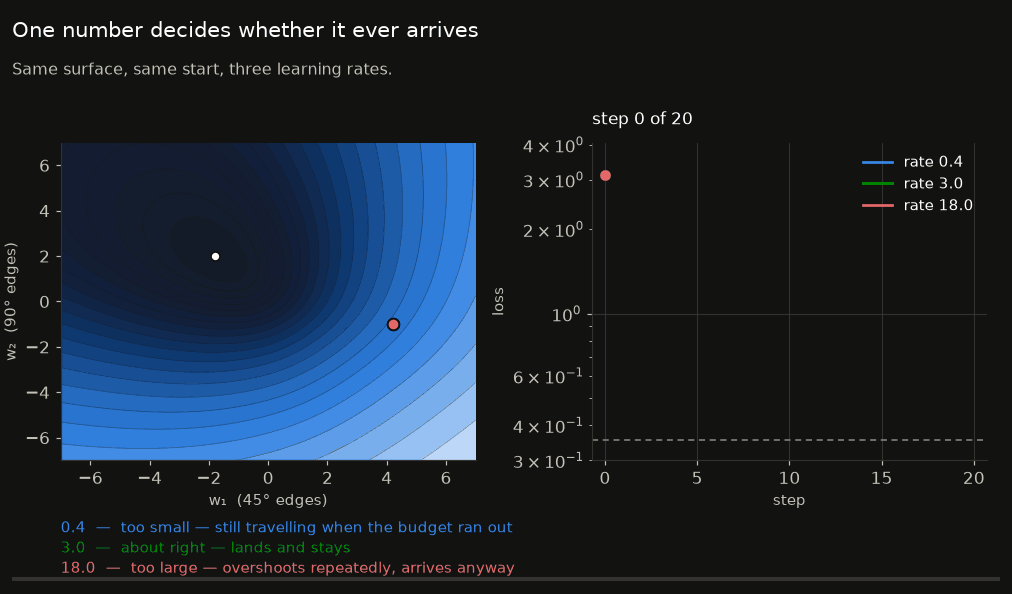

In [13]:
display(Image(filename=str(results.output_path("03_learning_rate.gif"))))


Note what the red run does **not** do: it arrives. It takes an absurd route —
out past $\lvert w \rvert = 6$, reversing seven times — but the loss it ends on
is the best of the three. "Too large" is a real failure mode, and this is not
quite it yet.

There is a threshold, though, and for this surface we can pin it down exactly.
Gradient descent on a quadratic bowl is stable precisely when

$$
\eta \;<\; \frac{2}{\lambda_{\max}}
$$

where $\lambda_{\max}$ is the largest eigenvalue of the Hessian — the curvature
in the steepest direction. Near the minimum our loss *is* effectively a
quadratic bowl, so the prediction should hold. Below we compute
$2/\lambda_{\max}$ from the Hessian, then find the true threshold by bisection:
run descent for 300 steps and ask whether it landed.


In [14]:
# Hessian of this loss at the optimum: Zᵀ diag(p(1−p)) Z / N.
p_star = 1.0 / (1.0 + np.exp(-(Z @ W_STAR)))
H = (Z * (p_star * (1 - p_star))[:, None]).T @ Z / len(y)
eigenvalues = np.linalg.eigvalsh(H)


def arrives(lr, steps=300):
    """Does descent at this rate end up at the minimum, or somewhere else?"""
    w = np.array(START, dtype=float)
    for _ in range(steps):
        w = w - lr * grad_at(w)
        if not np.all(np.isfinite(w)) or np.abs(w).max() > 1e6:
            return False
    return np.linalg.norm(w - W_STAR) < 1e-3


low, high = 1.0, 60.0            # low arrives, high does not
for _ in range(40):
    middle = (low + high) / 2
    low, high = (middle, high) if arrives(middle) else (low, middle)

print(f"Hessian eigenvalues at w*   {eigenvalues[0]:.5f}, {eigenvalues[1]:.5f}")
print(f"condition number            {eigenvalues[1] / eigenvalues[0]:.2f}")
print()
print(f"theory says the limit is    2/λmax = {2 / eigenvalues[1]:.3f}")
print(f"measured by bisection       {low:.3f}")
print(f"disagreement                {abs(low - 2 / eigenvalues[1]) / low:.2%}")


Hessian eigenvalues at w*   0.04115, 0.10501
condition number            2.55

theory says the limit is    2/λmax = 19.046
measured by bisection       19.115
disagreement                0.36%


Within half a percent. The stability limit of gradient descent is not folklore;
it is a property of the curvature, and it is sitting in this loss surface where
it can be measured.

This is also where the **condition number** earns its keep. It is the ratio of
the two eigenvalues — how much steeper the bowl is across than along. Ours is
about 2.5, a nearly round bowl, which is why a wide band of learning rates all
work. Real networks have condition numbers in the thousands, the useful band
narrows to almost nothing, and that single fact is why momentum, Adam and
learning-rate schedules exist at all.

## 9. The bowl was the easy case

Everything above lived on a convex surface. Two parameters, one basin, and any
downhill path reaches the bottom. It would be reasonable to conclude that
training is just this, scaled up.

It is not, and the cheapest way to show it is a straight line.

Train two networks from different random initialisations. Both reach about 93%.
Now walk in a straight line through parameter space from one to the other,
evaluating the loss along the way: $\theta(t) = (1-t)\,\theta_A + t\,\theta_B$.

If the loss were convex, the curve could never rise above the **chord** joining
the endpoints — that is the definition of convexity. Watch what it does.

*(This cell trains two networks from scratch in NumPy and takes two or three
minutes.)*


In [15]:
train_images, train_labels = load_mnist(train=True)
X_TRAIN, Y_TRAIN = train_images[:4000], train_labels[:4000]
X_EVAL, Y_EVAL = train_images[4000:4512], train_labels[4000:4512]


def build(seed):
    return Sequential(
        Conv2D(1, 6, kernel_size=5, padding=2, seed=seed), ReLU(), MaxPool2D(2),
        Conv2D(6, 12, kernel_size=5, padding=2, seed=seed + 1), ReLU(), MaxPool2D(2),
        Flatten(), Dense(12 * 7 * 7, 10, seed=seed + 2),
    )


def evaluate(net):
    logits = net.forward(X_EVAL)
    loss, _ = softmax_cross_entropy(logits, Y_EVAL)
    return loss, float((logits.argmax(1) == Y_EVAL).mean())


def train(net, steps=400, lr=0.15, batch=64, seed=0):
    """The same update rule as section 7, now over every parameter at once."""
    rng = np.random.default_rng(seed)
    for _ in range(steps):
        pick = rng.choice(len(X_TRAIN), size=batch, replace=False)
        _, gradient = softmax_cross_entropy(net.forward(X_TRAIN[pick]),
                                            Y_TRAIN[pick])
        net.backward(gradient)
        for name, parameter in net.params.items():
            parameter -= lr * net.grads[name]
    return net


A = train(build(1), seed=11)
B = train(build(40), seed=22)
loss_a, acc_a = evaluate(A)
loss_b, acc_b = evaluate(B)
print(f"network A   loss {loss_a:.4f}   accuracy {acc_a:.1%}")
print(f"network B   loss {loss_b:.4f}   accuracy {acc_b:.1%}")


network A   loss 0.1882   accuracy 93.6%
network B   loss 0.2658   accuracy 92.8%


In [16]:
PARAMS_A = {k: v.copy() for k, v in A.params.items()}
PARAMS_B = {k: v.copy() for k, v in B.params.items()}

ts = np.linspace(-0.08, 1.08, 45)
walk_loss, walk_acc = [], []
for t in ts:
    for name, parameter in A.params.items():
        parameter[...] = (1 - t) * PARAMS_A[name] + t * PARAMS_B[name]
    loss, acc = evaluate(A)
    walk_loss.append(loss)
    walk_acc.append(acc)

walk_loss, walk_acc = np.array(walk_loss), np.array(walk_acc)
inside = (ts >= 0) & (ts <= 1)
peak = walk_loss[inside].max()
worse_end = max(loss_a, loss_b)

print(f"highest loss on the segment   {peak:.3f}  at t = "
      f"{ts[inside][walk_loss[inside].argmax()]:.2f}")
print(f"worse endpoint                {worse_end:.3f}")
print(f"barrier                       {peak / worse_end:.1f}× the worse endpoint")
print(f"lowest accuracy on the way    {walk_acc[inside].min():.1%}")


highest loss on the segment   1.752  at t = 0.42
worse endpoint                0.266
barrier                       6.6× the worse endpoint
lowest accuracy on the way    55.7%


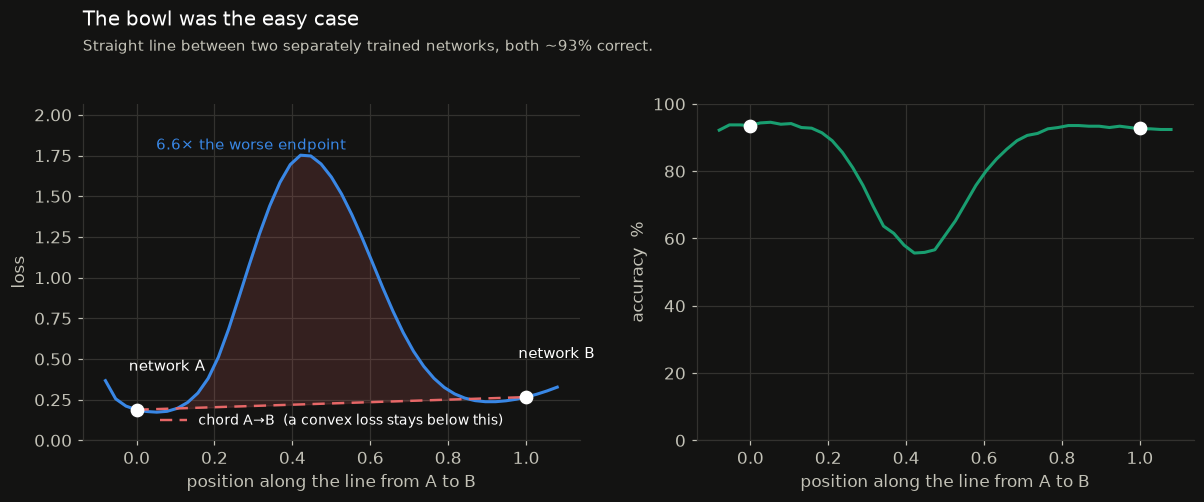

In [17]:
# Explicit positions rather than constrained layout: the layout engine reserves
# room for a suptitle but not for a plain fig.text, so an automatically placed
# subtitle lands on top of the left panel's tick labels.
fig = plt.figure(figsize=(11.0, 4.6))
fig.set_layout_engine("none")
gs = GridSpec(1, 2, figure=fig, left=0.062, right=0.980, top=0.800,
              bottom=0.135, wspace=0.235)

ax = fig.add_subplot(gs[0, 0])
ax.plot(ts, walk_loss, color=style.CATEGORICAL[0], zorder=3)
chord = np.interp(ts, [0, 1], [loss_a, loss_b])
ax.plot([0, 1], [loss_a, loss_b], color=style.CATEGORICAL[7],
        linestyle=(0, (5, 3)), linewidth=1.6, zorder=4,
        label="chord A→B  (a convex loss stays below this)")
ax.fill_between(ts[inside], chord[inside], walk_loss[inside],
                where=walk_loss[inside] > chord[inside],
                color=style.CATEGORICAL[7], alpha=0.16, zorder=2)
for t_at, value, name in ((0.0, loss_a, "A"), (1.0, loss_b, "B")):
    ax.plot([t_at], [value], "o", color=style.FOCUS, markersize=8, zorder=5)
    ax.annotate(text.t("barrier_solution", name=name), xy=(t_at, value),
                xytext=(t_at - 0.02, value + 0.24), fontsize=10, color=style.FOCUS)
ax.annotate(text.t("barrier_peak", v=text.num(peak / worse_end, 1)),
            xy=(ts[inside][walk_loss[inside].argmax()], peak),
            xytext=(0.05, peak * 1.02), fontsize=10, color=style.CATEGORICAL[0])
ax.set_xlabel(text.t("barrier_x"))
ax.set_ylabel(text.t("loss_axis"))
ax.set_ylim(0, peak * 1.18)
ax.legend(loc="lower center", fontsize=9)

ax = fig.add_subplot(gs[0, 1])
ax.plot(ts, walk_acc * 100, color=style.CATEGORICAL[4])
ax.plot([0, 1], [acc_a * 100, acc_b * 100], "o", color=style.FOCUS,
        markersize=8, zorder=5)
ax.set_xlabel(text.t("barrier_x"))
ax.set_ylabel(f"{text.t('accuracy_axis')}  %")
ax.set_ylim(0, 100)

fig.text(0.062, 0.955, text.t("barrier_title"), fontsize=13,
         color=style.INK_PRIMARY)
fig.text(0.062, 0.905, text.t("barrier_subtitle"), fontsize=10,
         color=style.INK_SECONDARY)

fig.savefig(results.output_path("loss_barrier.png", notebook=NOTEBOOK))
plt.show()


The loss climbs to more than six times the worse endpoint, and accuracy falls
from 93% to the mid-fifties, on a path whose two ends are both good networks.
A convex function cannot do that. The shaded region is the proof, and it is
measured, not drawn.

So the mental picture to carry forward is not one bowl. It is a landscape with
many separate basins, of which A and B are two, and between them a ridge that
neither would ever cross. Gradient descent never sees the ridge, because it
only ever goes downhill from where it happens to start — which is also the
answer to "why does the random seed matter".

What survives from the bowl is the mechanism, and it survives intact: the
gradient still points the steepest way down, the learning rate still decides
whether you arrive, and the stability limit is still set by curvature. What
does not survive is the guarantee that *down* means *best*.

## 10. A cut for a narrow canvas

The wide layout above reads at leisure on a laptop. Scaled into a phone feed,
the two panels leave the contour a few hundred pixels across and the type a few
pixels tall.

As in notebook 02, the fix is a different layout on a different canvas: 4:5
portrait at 1080×1350, panels stacked rather than side by side, roughly double
the type, and a title short enough to read while scrolling. `mp4=True` writes
an H.264 file beside the GIF, because Instagram and TikTok reject GIF uploads.

Three things differ from notebook 02's feed cut, and all three are about the
fact that nobody *studies* a feed post.

**It ships in Brazilian Portuguese.** The notebook figures document the work
and stay in English; this one gets posted, and it gets posted to a Portuguese
-speaking audience. Because every label comes from `cnnviz.text`, that is one
line rather than a second figure — and `text.num` follows, so the loss reads
`0,609` rather than `0.609`.

**It runs slower.** The wide cut is watched by someone who can scrub back. This
one is watched once, muted, mid-scroll. The base rate drops from 7 fps to 5,
and the frames are held where the argument is: the step length falls from 100%
to 16% of its opening value between steps 3 and 8, and if that goes past in
under a second there was no point drawing it. About sixteen seconds in total —
comfortably over the ~3 second floor a feed enforces, and well under the point
where anyone scrolls away.

**Its captions are the `*_short` strings.** This is not a refinement; the full
ones do not fit. A caption is set across the whole canvas rather than into a
panel, so it overruns before a title does, and it changes every frame — which
is exactly how a clipped line reaches a published GIF unnoticed. Two of the
English captions overran at this size before the short forms existed, and the
Portuguese ones, 12% longer again, overran worse.
`test_short_captions_fit_the_portrait_canvas` now measures the rendered text
against the canvas in both languages, so the next translation fails a test
rather than a post.


In [18]:
CANVAS = formats.FEED_PORTRAIT

# The one artefact in this notebook that ships localised. Set before the frame
# callback is defined so every text.t() inside it resolves in Portuguese, and
# put back at the end of the cell so the results index below is English again.
text.set_language("pt-BR")


def feed_caption_for(k):
    """Same phases as `caption_for`, in the short strings this canvas needs."""
    if k == 0:
        return text.t("descent_cap_start_short")
    if k <= 2:
        return text.t("descent_cap_gradient_short")
    if k <= 8:
        return text.t("descent_cap_steep_short")
    if k < STEPS:
        return text.t("descent_cap_flat_short")
    return text.t("descent_cap_end_short")


def draw_feed(fig, k):
    gs = GridSpec(1, 1, figure=fig, left=0.135, right=0.945, top=0.815,
                  bottom=0.395)
    ax = fig.add_subplot(gs[0, 0])
    ax.contourf(W1, W2, L, levels=LEVELS, cmap=style.CMAP_MAGNITUDE)
    ax.contour(W1, W2, L, levels=LEVELS, colors=style.SURFACE, linewidths=0.7,
               alpha=0.45)
    ax.plot([W_STAR[0]], [W_STAR[1]], "o", color=style.FOCUS, markersize=9,
            markeredgecolor=style.SURFACE, markeredgewidth=1.8, zorder=6)

    walked = PATH[:k + 1]
    ax.plot(walked[:, 0], walked[:, 1], "-", color=style.FOCUS, linewidth=2.2,
            alpha=0.85, zorder=7)
    here = walked[-1]
    if k < STEPS:
        step = -LR * grad_at(here)
        ax.add_patch(FancyArrowPatch(
            tuple(here), tuple(here + step), arrowstyle="-|>", mutation_scale=24,
            linewidth=3.2, color=style.CATEGORICAL[3], zorder=8,
            shrinkA=13.0, shrinkB=0.0,
        ))
    ax.plot([here[0]], [here[1]], "o", color=style.CATEGORICAL[3], markersize=14,
            markeredgecolor=style.SURFACE, markeredgewidth=2.2, zorder=9)
    ax.set_xlim(-LIM, LIM)
    ax.set_ylim(-LIM, LIM)
    ax.grid(False)
    ax.set_xlabel(text.t("w1_axis"), fontsize=CANVAS.pt(9))
    ax.set_ylabel(text.t("w2_axis"), fontsize=CANVAS.pt(9))
    ax.tick_params(labelsize=CANVAS.pt(8))

    gs2 = GridSpec(1, 1, figure=fig, left=0.135, right=0.945, top=0.325,
                   bottom=0.145)
    ax2 = fig.add_subplot(gs2[0, 0])
    ax2.plot(np.arange(k + 1), LOSSES[:k + 1], color=style.CATEGORICAL[3],
             linewidth=3.0)
    ax2.axhline(L_STAR, color=style.INK_MUTED, linestyle=(0, (4, 3)),
                linewidth=1.6)
    ax2.plot([k], [LOSSES[k]], "o", color=style.CATEGORICAL[3], markersize=11)
    ax2.set_xlim(-0.7, STEPS + 0.7)
    ax2.set_ylim(0, LOSSES.max() * 1.06)
    ax2.set_xlabel(text.t("step_axis"), fontsize=CANVAS.pt(9))
    ax2.set_ylabel(text.t("loss_axis"), fontsize=CANVAS.pt(9))
    ax2.tick_params(labelsize=CANVAS.pt(8))

    fig.text(0.135, 0.955, text.t("descent_title_short"), ha="left", va="top",
             fontsize=CANVAS.pt(15), color=style.INK_PRIMARY)
    fig.text(0.135, 0.912, text.t("descent_subtitle_short"), ha="left", va="top",
             fontsize=CANVAS.pt(10.5), color=style.INK_SECONDARY)
    fig.text(0.135, 0.868,
             f"{text.t('step_of', k=k, n=STEPS)}   ·   "
             f"{text.t('loss_now', v=text.num(LOSSES[k], 3))}",
             ha="left", va="top", fontsize=CANVAS.pt(10.5),
             color=style.CATEGORICAL[3])
    panels.caption(fig, feed_caption_for(k), y=0.062, x=0.135,
                   fontsize=CANVAS.pt(9.5))
    panels.progress_bar(fig, k / STEPS, y=0.034, x=0.135, width=0.81, height=0.007)


# Hold where the step is visibly collapsing. Between steps 3 and 8 the step
# length falls from 78% of its opening value to 16%, which is the whole claim
# of the animation; at a flat 5 fps it goes past in a second.
FEED_HOLDS = {0: 1.3, 1: 0.75, 2: 0.65, 3: 0.5, 4: 0.4, 5: 0.3, 6: 0.25,
              7: 0.2, 8: 0.15}
FEED_DURATIONS = animate.hold_at(len(PATH), fps=5, holds=FEED_HOLDS,
                                 first=1.6, last=3.0)
print(f"feed cut: {len(PATH)} frames, {sum(FEED_DURATIONS) / 1000:.1f}s")

animate.animate(
    draw_feed, len(PATH),
    results.output_path("gradient_descent_feed.gif", notebook=NOTEBOOK),
    figsize=CANVAS.figsize, fps=5, durations=FEED_DURATIONS,
    # 160 rather than the default 96: a frame mixing the contour ramp with the
    # marker and arrow bands visibly at the lower count.
    colors=160, mp4=True,
)

# Back to English: every cell below this one, and any re-run of the cells
# above, renders in the language the rest of the series ships in.
text.set_language("en")


feed cut: 33 frames, 15.7s


03_gradient_descent_feed:   0%|          | 0/33 [00:00<?, ?frame/s]

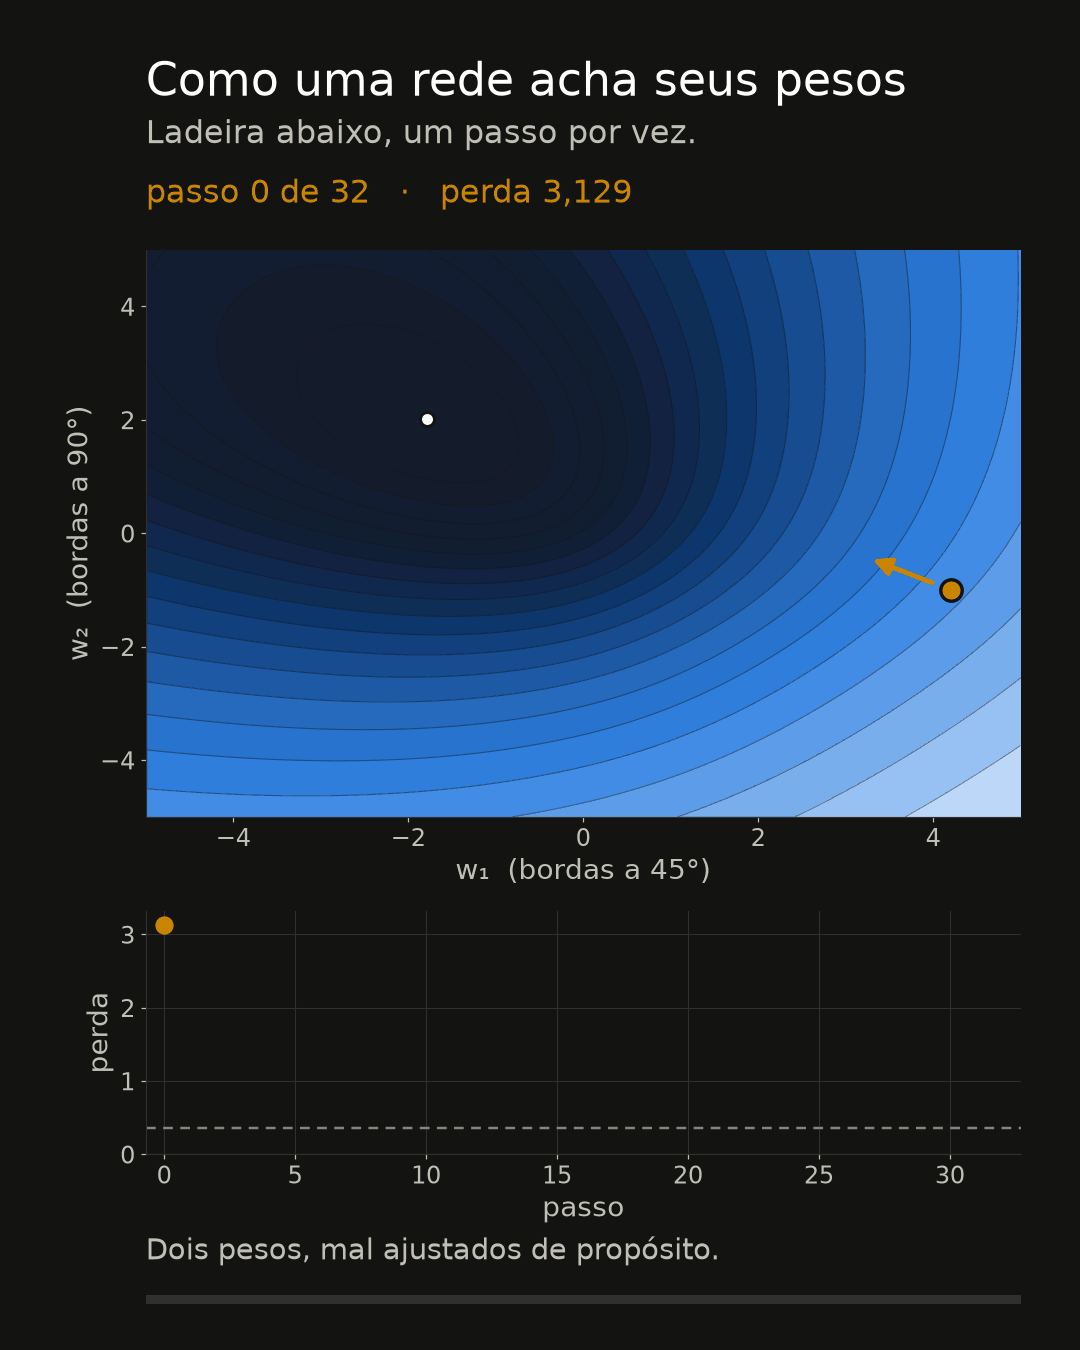

In [19]:
display(Image(filename=str(results.output_path("03_gradient_descent_feed.gif"))))


## 11. Refresh the results index


In [20]:
results.write_index()

for item in results.list_results("03_*"):
    print(f"{item.name:36s} {item.stat().st_size / 1e6:6.2f} MB")


03_cross_entropy.png                   0.05 MB
03_feature_space.png                   0.10 MB
03_gradient_descent.gif                0.12 MB
03_gradient_descent_feed.gif           0.20 MB
03_gradient_descent_feed.mp4           0.49 MB
03_landscape_2d.png                    0.09 MB
03_learning_rate.gif                   0.09 MB
03_loss_barrier.png                    0.07 MB
03_slice_1d.png                        0.04 MB
03_steepest_direction.png              0.05 MB


## 12. What we have, and what is missing

Five things, each measured rather than asserted:

1. **A loss is one number, and cross-entropy is unbounded above.** Confident
   and wrong costs arbitrarily much, which is what stops a network bluffing.
2. **The loss is a surface over the parameters.** With two parameters we drew
   the whole of it — no slice, no projection.
3. **The gradient is the steepest descent direction**, confirmed against 24
   probes that landed on the predicted cosine. Half of all directions make
   things worse.
4. **The learning rate decides whether descent arrives**, and its stability
   limit is $2/\lambda_{\max}$ — predicted from the Hessian and measured by
   bisection, agreeing to half a percent.
5. **Real landscapes are not bowls.** The straight line between two 93%
   networks climbs to six times their loss and drops to 55% accuracy.

And here is the gap. Every gradient in this notebook came from a model so
small we could differentiate it by hand — one logit, two weights,
$\partial L/\partial \mathbf{w} = Z^{\top}(p - y)/N$ in a single line.

The network in section 9 has about twenty thousand parameters, arranged in
layers that feed each other. Its gradient came from `net.backward(...)`, which
this notebook used without opening. That is the one piece of machinery still
in the box, and it is the piece that makes all of the above apply to something
worth training.

**Next:** `04_backpropagation.ipynb` — how the error at the output becomes a
gradient for a kernel four layers upstream, one chain-rule link at a time.
